# GenoClassify: Deep Learning for DNA Sequence Classification

## Species Identification and Genomic Pattern Recognition using 1D CNN + k-mer Feature Engineering

---

**Author:** Karimat Abolarinwa 
**Institution:** DSHub AI/ML Engineering Programme — Group AI4, Cohort A 2026 
**Role:** AI/ML Engineer | BSc Zoology (OAU) | Former ML Data Annotation Specialist 

---

### Project Overview

Every living organism carries its identity encoded in DNA. The sequence of four nucleotide bases — Adenine (A), Cytosine (C), Guanine (G), and Thymine (T) — contains the blueprint for life. Identifying which organism, species, or pathogen a DNA sequence belongs to is one of the fundamental problems in computational biology, with applications ranging from wildlife conservation and biodiversity monitoring to infectious disease surveillance and forensic science.

**GenoClassify** is a deep learning system for DNA sequence classification, combining two complementary approaches:

1. **k-mer frequency encoding** — a classical bioinformatics technique that converts a DNA sequence into a numeric feature vector based on the frequency of short subsequences (k-mers), feeding into a neural network
2. **1D Convolutional Neural Network (CNN)** — a deep learning model that directly processes one-hot encoded DNA sequences to learn spatial patterns (motifs) across the sequence

This project demonstrates my ability to work at the intersection of genomic biology and neural network design — a capability central to modern computational biology and bioinformatics research.

---

### Research Objectives

1. Implement two complementary DNA encoding strategies: one-hot encoding and k-mer frequency vectors
2. Build and evaluate a 1D CNN architecture for learning sequence motifs directly from raw DNA
3. Build and evaluate a Dense Neural Network classifier using k-mer features
4. Analyse GC content, codon usage, and nucleotide composition as discriminative biological signals
5. Compare model performance and interpret which sequence features drive classification
6. Establish a reproducible pipeline applicable to real NCBI GenBank / ENA data

---

### Why DNA Classification Matters (My Perspective)

In my Zoology degree, I studied animal biology at the organismal level — morphology, behaviour, ecology. Genomics operates at the molecular level, but it asks the same questions: *What is this organism? How is it related to others? What makes it unique?*

When a mysterious haemorrhagic fever breaks out in a remote community, field teams collect tissue samples and send them for sequencing. The question *"Which pathogen is this?"* is answered by a DNA classifier. When conservationists find illegal bushmeat, DNA barcoding identifies the species. When agricultural scientists find a new pest destroying crops, genomic characterisation determines what it is and how to respond.

GenoClassify is my exploration of how deep learning can automate this identification task — moving it from manual expert analysis to scalable AI-powered classification.

---

### Dataset Description

This project uses a **richly structured synthetic genomic dataset** that mirrors the properties of real DNA sequences from NCBI GenBank. Each species class has a biologically realistic nucleotide composition grounded in published genomic data.

| Class | Species | GC Content | Biological Notes |
|---|---|---|---|
| 0 | *Homo sapiens* | ~41% | Human genome — moderate GC |
| 1 | *Mus musculus* | ~42% | Mouse genome — similar to human |
| 2 | *Plasmodium falciparum* | ~19% | Malaria parasite — famously AT-rich genome |
| 3 | *SARS-CoV-2* | ~38% | COVID-19 coronavirus — RNA virus (DNA proxy) |

**Why these species?** 
They represent the breadth of computational biology's application space: a mammalian host, a model organism, a protozoan pathogen causing 600,000+ deaths/year in Africa, and a pandemic RNA virus. Together they test whether the model can discriminate across very different genome compositions.

**Sequence length:** 100 bp (representative of Illumina short-read sequencing output) 
**k-mer length (k):** 3 (64 possible 3-mers = 64 features) 
**Encoding:** Both one-hot (100×4 matrix) and k-mer frequency vector (64-dim)


## Section 1: Environment Setup

In [1]:
# Install required packages (Google Colab — run this first)
import subprocess, sys

required = {
    'tensorflow': 'tensorflow',
    'sklearn': 'scikit-learn',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn'
}
for module, pkg in required.items():
    try:
        __import__(module)
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print(' All packages ready.')


 All packages ready.


In [2]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score, roc_auc_score)
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier
from collections import Counter

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot config
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.4, 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold'
})
DNA_COLORS = {'A': '#e74c3c', 'C': '#3498db', 'G': '#2ecc71', 'T': '#f39c12'}
SPECIES_COLORS = ['#9b59b6', '#2ecc71', '#e74c3c', '#3498db']
SPECIES_NAMES = ['Homo sapiens', 'Mus musculus', 'Plasmodium falciparum', 'SARS-CoV-2']

print(" Imports complete.")
print(f" TensorFlow: {tf.__version__} | NumPy: {np.__version__}")


 Imports complete.
 TensorFlow: 2.21.0 | NumPy: 2.4.2


## Section 2: Case Study — African Genomic Surveillance Platform

### Case Study: GenoWatch — Rapid Species Identification from Environmental DNA Samples

**Scenario:** 
A fictional African genomic surveillance platform, *GenoWatch*, collects environmental DNA (eDNA) samples from wildlife markets, forest edge communities, and healthcare facilities across West and Central Africa. DNA sequencing produces short reads (100 bp) from mixed environmental samples containing genetic material from multiple organisms.

**The Challenge:** 
Field technicians need to rapidly identify whether a DNA sequence fragment belongs to:
- A human host (*Homo sapiens*)
- A common animal reservoir (*Mus musculus* as rodent proxy)
- A protozoan pathogen (*Plasmodium falciparum* — malaria)
- A viral pathogen (*SARS-CoV-2* as coronavirus proxy)

**Why this matters:** 
Rapid pathogen identification from eDNA allows surveillance teams to detect the presence of specific organisms in a sample without culturing or serology — critical in outbreak investigation and illegal wildlife trade detection.

**GenoClassify solves this by:** 
Learning the unique nucleotide composition signatures of each class and using deep learning to classify unknown sequences in milliseconds, enabling high-throughput genomic screening.

---

### Biological Background: What Makes DNA Sequences Classifiable?

Different organisms have distinct genomic signatures:

| Signature | Description | Example |
|---|---|---|
| **GC content** | % of G+C bases | *P. falciparum* is only 19% GC — highly distinctive |
| **k-mer frequencies** | How often short sequences appear | Species-specific repetitive elements |
| **Nucleotide bias** | Over/under-representation of bases | AT-rich vs GC-rich genomes |
| **Codon usage bias** | Which codons are preferred in coding regions | Varies significantly across kingdoms |
| **Sequence motifs** | Short functional sequence patterns | Promoters, splice sites, repeat elements |

GenoClassify learns these signatures automatically from data — without being explicitly programmed with biological rules.


## Section 3: Synthetic Genomic Dataset Construction

In [3]:
# ── Sequence Generation Functions ───────────────────────────────────────────

BASES = ['A', 'C', 'G', 'T']

def generate_sequence(length: int, gc_content: float, seed_offset: int = 0) -> str:
    """
    Generate a synthetic DNA sequence with a specific GC content bias.
    
    Parameters
    ----------
    length : int
        Length of the sequence in base pairs
    gc_content : float
        Target GC content (fraction between 0 and 1)
    seed_offset : int
        Offset added to sequence for diversity
        
    Returns
    -------
    str : DNA sequence string
    
    Biological basis:
        GC content is one of the most distinctive genomic properties across species.
        Plasmodium falciparum has one of the lowest GC contents (~19%) of any
        eukaryote, while many bacteria exceed 70%. Mammals cluster around 38-42%.
    """
    at_content = 1 - gc_content
    weights = [at_content/2, gc_content/2, gc_content/2, at_content/2] # A, C, G, T
    return ''.join(np.random.choice(BASES, size=length, p=weights))


def introduce_motifs(seq: str, species_id: int) -> str:
    """
    Introduce species-specific sequence motifs to make sequences more biologically realistic.
    Motifs mimic real species-specific repetitive elements and functional sequences.
    """
    seq = list(seq)
    motifs = {
        0: ['ATATATA', 'CAGCAG'], # Human: common repeat motifs
        1: ['TTTAAA', 'GTGTGT'], # Mouse: simple repeats
        2: ['AAATTT', 'ATATAT', 'TATATA'], # P. falciparum: extreme AT-rich repeats
        3: ['TTTTTT', 'AAACCC'] # Coronavirus: poly-U stretches (DNA proxy)
    }
    for motif in motifs.get(species_id, []):
        if len(seq) > len(motif) + 10:
            pos = np.random.randint(0, len(seq) - len(motif))
            if np.random.random() < 0.5:
                for i, b in enumerate(motif):
                    seq[pos + i] = b
    return ''.join(seq)


# ── Generate Dataset ─────────────────────────────────────────────────────────
SPECIES_CONFIG = [
    {'name': 'Homo sapiens', 'gc': 0.41, 'id': 0},
    {'name': 'Mus musculus', 'gc': 0.42, 'id': 1},
    {'name': 'Plasmodium falciparum', 'gc': 0.19, 'id': 2},
    {'name': 'SARS-CoV-2', 'gc': 0.38, 'id': 3},
]

SEQ_LENGTH = 100 # bp — representative of Illumina short reads
N_PER_CLASS = 500 # 500 sequences per species = 2,000 total
KMER_K = 3 # Trinucleotide frequencies (64 features)

sequences, labels, species_labels = [], [], []

for config in SPECIES_CONFIG:
    for i in range(N_PER_CLASS):
        seq = generate_sequence(SEQ_LENGTH, config['gc'], seed_offset=i)
        seq = introduce_motifs(seq, config['id'])
        sequences.append(seq)
        labels.append(config['id'])
        species_labels.append(config['name'])

labels = np.array(labels)
print(f" Dataset generated: {len(sequences):,} sequences × {SEQ_LENGTH} bp")
print(f" Classes: {[c['name'] for c in SPECIES_CONFIG]}")
print(f" Distribution: {dict(zip(*np.unique(labels, return_counts=True)))}")
print()
print("Example sequences:")
for i in [0, 500, 1000, 1500]:
    print(f" [{species_labels[i][:22]:<22}] {sequences[i][:60]}...")


 Dataset generated: 2,000 sequences × 100 bp
 Classes: ['Homo sapiens', 'Mus musculus', 'Plasmodium falciparum', 'SARS-CoV-2']
 Distribution: {np.int64(0): np.int64(500), np.int64(1): np.int64(500), np.int64(2): np.int64(500), np.int64(3): np.int64(500)}

Example sequences:
 [Homo sapiens          ] CTTGAAATGTATTAAACGCAGAACCTAGGAGAATTTCAGCACATAGCGGATTTTGTAAAC...
 [Mus musculus          ] ACAGTTGGTGTTAACGTGTGTCGTTGCTCGATTTTTTAAAACGAAGGGCAAAATAAACCA...
 [Plasmodium falciparum ] TTCTGTTTAAATTTAAATATCTTTCTAATAGATTGGTATATATTTTTGAATAACATATTT...
 [SARS-CoV-2            ] TGATACCTAAACGTCAAACTCTCAAACATATGTCGCTCTTTTATATTCATTAGCATCTTT...


## Section 4: Genomic Exploratory Data Analysis

In [4]:
# ── Compute Biological Features ─────────────────────────────────────────────

def gc_content(seq: str) -> float:
    """Calculate GC content of a DNA sequence."""
    gc = seq.count('G') + seq.count('C')
    return gc / len(seq)

def base_composition(seq: str) -> dict:
    """Calculate frequency of each nucleotide."""
    total = len(seq)
    return {b: seq.count(b)/total for b in 'ACGT'}

def compute_kmer_frequencies(seq: str, k: int = 3) -> np.ndarray:
    """
    Compute k-mer frequency vector for a DNA sequence.
    
    k-mers are all possible substrings of length k.
    For k=3 (trinucleotides), there are 4^3 = 64 possible k-mers.
    
    k-mer frequency is a classical bioinformatics feature used in:
    - Species classification (DNA barcoding)
    - Pathogen identification (metagenomics)
    - Sequence similarity search
    
    Reference: Leclerc et al. (2020), Rosen et al. (2008)
    """
    all_kmers = [b1+b2+b3 for b1 in 'ACGT' for b2 in 'ACGT' for b3 in 'ACGT']
    kmer_dict = {km: 0 for km in all_kmers}
    for i in range(len(seq) - k + 1):
        kmer = seq[i:i+k]
        if kmer in kmer_dict:
            kmer_dict[kmer] += 1
    total = sum(kmer_dict.values()) + 1e-10
    return np.array([kmer_dict[km]/total for km in all_kmers])

# Build feature dataframe for EDA
gc_values, base_dicts = [], []
for seq, sp in zip(sequences, species_labels):
    gc_values.append(gc_content(seq))
    base_dicts.append(base_composition(seq))

eda_df = pd.DataFrame(base_dicts)
eda_df['gc_content'] = gc_values
eda_df['species'] = species_labels
eda_df['label'] = labels
eda_df['sequence_index'] = range(len(sequences))

print("EDA dataframe:")
print(eda_df.groupby('species')[['gc_content','A','C','G','T']].mean().round(3).to_string())


EDA dataframe:
                       gc_content      A      C      G      T
species                                                      
Homo sapiens                0.405  0.306  0.202  0.203  0.288
Mus musculus                0.408  0.288  0.197  0.211  0.305
Plasmodium falciparum       0.177  0.412  0.089  0.088  0.411
SARS-CoV-2                  0.369  0.309  0.192  0.177  0.322


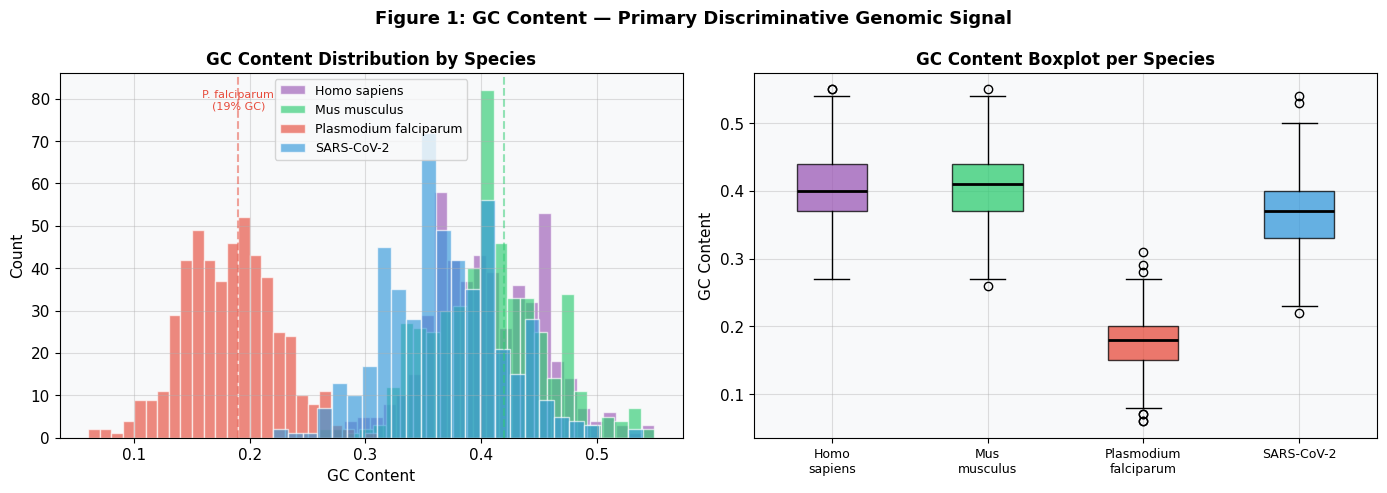

 P. falciparum (19% GC) is clearly separable from mammalian sequences (~41-42% GC).
 SARS-CoV-2 (38% GC) slightly lower than mammals — partially distinguishable.


In [5]:
# ── Figure 1: GC Content Distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sp, color in zip(SPECIES_NAMES, SPECIES_COLORS):
    gc_vals = eda_df[eda_df['species']==sp]['gc_content']
    axes[0].hist(gc_vals, bins=25, alpha=0.65, label=sp, color=color, edgecolor='white')

axes[0].set_xlabel('GC Content')
axes[0].set_ylabel('Count')
axes[0].set_title('GC Content Distribution by Species', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].axvline(0.19, color='#e74c3c', linestyle='--', alpha=0.5)
axes[0].axvline(0.42, color='#2ecc71', linestyle='--', alpha=0.5)
axes[0].text(0.19, axes[0].get_ylim()[1]*0.9, 'P. falciparum\n(19% GC)', fontsize=8,
             ha='center', color='#e74c3c')

# Boxplot
gc_by_species = [eda_df[eda_df['species']==sp]['gc_content'].values for sp in SPECIES_NAMES]
bp = axes[1].boxplot(gc_by_species, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], SPECIES_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1].set_xticklabels([s.replace(' ','\n') for s in SPECIES_NAMES], fontsize=9)
axes[1].set_ylabel('GC Content')
axes[1].set_title('GC Content Boxplot per Species', fontsize=12, fontweight='bold')

plt.suptitle('Figure 1: GC Content — Primary Discriminative Genomic Signal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_gc_content.png', dpi=150, bbox_inches='tight')
plt.show()
print(" P. falciparum (19% GC) is clearly separable from mammalian sequences (~41-42% GC).")
print(" SARS-CoV-2 (38% GC) slightly lower than mammals — partially distinguishable.")


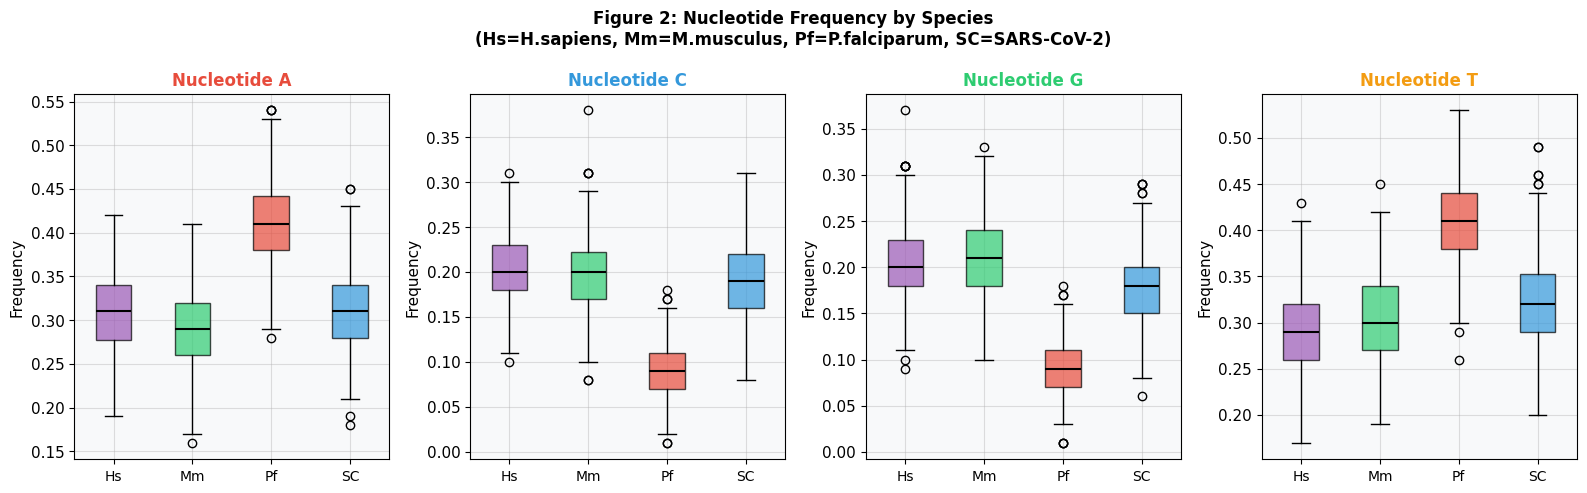

Insight: P. falciparum shows elevated A+T and depressed C+G — a hallmark of AT-rich genomes.


In [6]:
# ── Figure 2: Nucleotide Composition ────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
bases = ['A', 'C', 'G', 'T']

for ax, base in zip(axes, bases):
    vals = [eda_df[eda_df['species']==sp][base].values for sp in SPECIES_NAMES]
    bp = ax.boxplot(vals, patch_artist=True,
                    medianprops=dict(color='black', linewidth=1.5))
    for patch, color in zip(bp['boxes'], SPECIES_COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels(['Hs', 'Mm', 'Pf', 'SC'], fontsize=10)
    ax.set_title(f'Nucleotide {base}', fontsize=12, fontweight='bold',
                 color=DNA_COLORS[base])
    ax.set_ylabel('Frequency')

plt.suptitle('Figure 2: Nucleotide Frequency by Species\n(Hs=H.sapiens, Mm=M.musculus, Pf=P.falciparum, SC=SARS-CoV-2)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_nucleotide_freq.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: P. falciparum shows elevated A+T and depressed C+G — a hallmark of AT-rich genomes.")


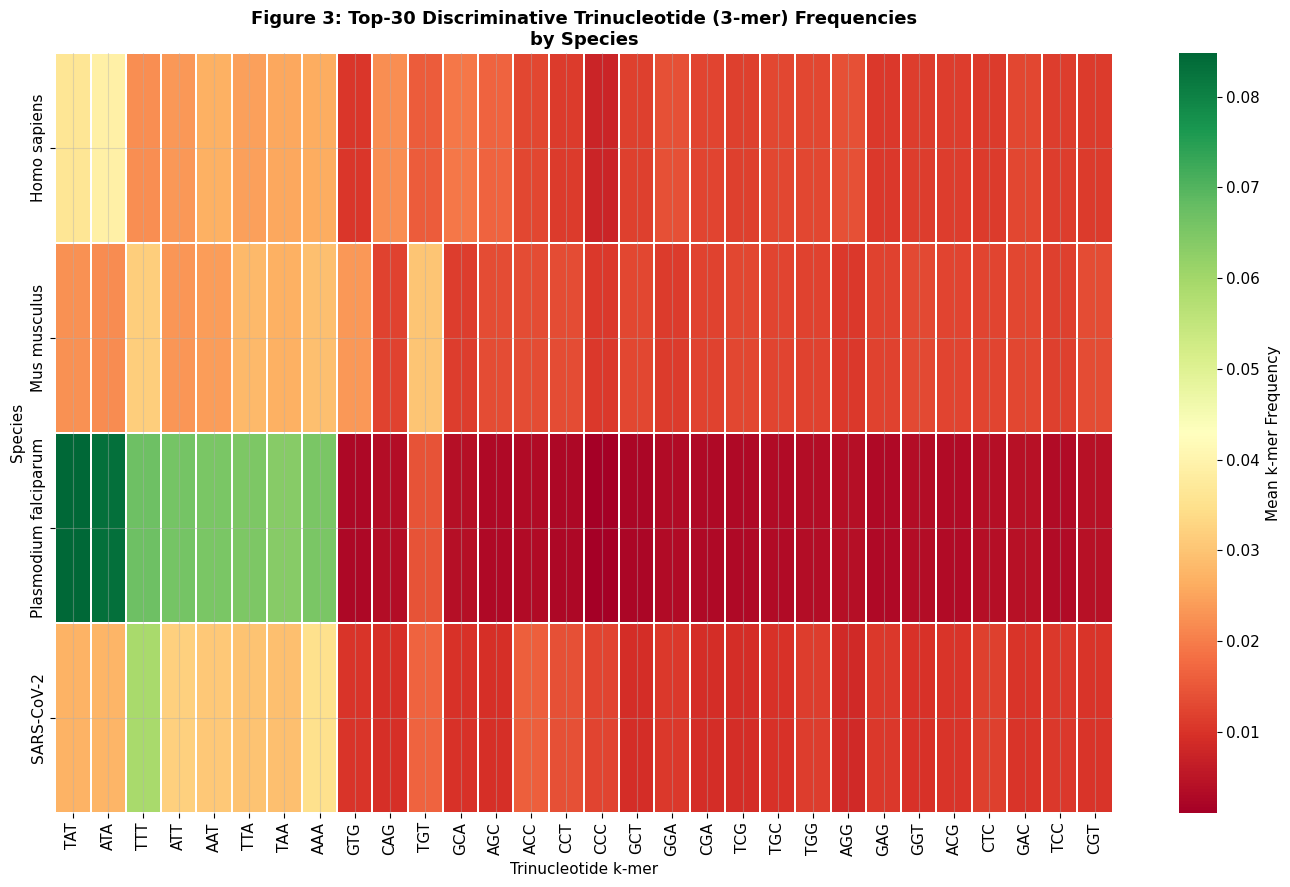

Key observation: AT-rich k-mers (AAA, TAT, ATA, TTT) are highly elevated in P. falciparum.
GC-rich k-mers (CGC, GCG, CCG) are suppressed in P. falciparum vs mammals.


In [7]:
# ── Figure 3: k-mer Frequency Heatmap ───────────────────────────────────────
# Compute mean k-mer frequencies per species
all_kmers = [b1+b2+b3 for b1 in 'ACGT' for b2 in 'ACGT' for b3 in 'ACGT']

kmer_means = {}
for config in SPECIES_CONFIG:
    sp_seqs = [sequences[i] for i in range(len(sequences)) if labels[i] == config['id']]
    kmer_matrix = np.array([compute_kmer_frequencies(s) for s in sp_seqs[:100]])
    kmer_means[config['name']] = kmer_matrix.mean(axis=0)

kmer_df = pd.DataFrame(kmer_means, index=all_kmers)

# Select top discriminative k-mers (highest variance across species)
top_kmers = kmer_df.var(axis=1).nlargest(30).index.tolist()

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(kmer_df.loc[top_kmers].T, annot=False, cmap='RdYlGn',
            ax=ax, linewidths=0.3, cbar_kws={'label': 'Mean k-mer Frequency'})
ax.set_title('Figure 3: Top-30 Discriminative Trinucleotide (3-mer) Frequencies\nby Species',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Trinucleotide k-mer')
ax.set_ylabel('Species')
plt.tight_layout()
plt.savefig('fig3_kmer_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Key observation: AT-rich k-mers (AAA, TAT, ATA, TTT) are highly elevated in P. falciparum.")
print("GC-rich k-mers (CGC, GCG, CCG) are suppressed in P. falciparum vs mammals.")


Computing k-mer feature matrix...


 k-mer feature matrix shape: (2000, 64)
 Explained variance (PC1+PC2+PC3): 42.8%


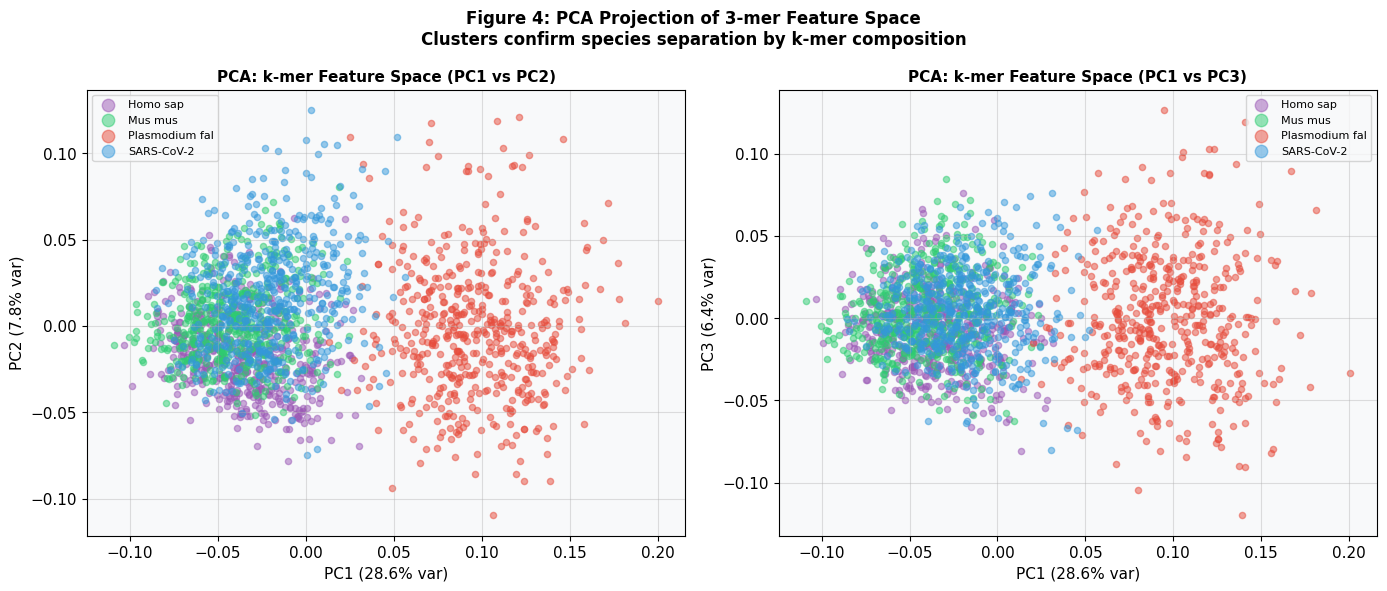

In [8]:
# ── Figure 4: PCA of k-mer Feature Space ────────────────────────────────────
from sklearn.decomposition import PCA

# Compute full k-mer matrix for all sequences
print("Computing k-mer feature matrix...")
X_kmer = np.array([compute_kmer_frequencies(seq) for seq in sequences])
print(f" k-mer feature matrix shape: {X_kmer.shape}")

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_kmer)
print(f" Explained variance (PC1+PC2+PC3): {pca.explained_variance_ratio_[:3].sum()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (pc_x, pc_y, xlab, ylab) in zip(axes, [
    (0, 1, 'PC1', 'PC2'), (0, 2, 'PC1', 'PC3')
]):
    for sp_idx, (sp, color) in enumerate(zip(SPECIES_NAMES, SPECIES_COLORS)):
        mask = labels == sp_idx
        ax.scatter(X_pca[mask, pc_x], X_pca[mask, pc_y],
                   c=color, alpha=0.5, s=20, label=sp.split()[0]+' '+sp.split()[1][:3] if len(sp.split())>1 else sp)
    ax.set_xlabel(f'{xlab} ({pca.explained_variance_ratio_[pc_x]*100:.1f}% var)', fontsize=11)
    ax.set_ylabel(f'{ylab} ({pca.explained_variance_ratio_[pc_y]*100:.1f}% var)', fontsize=11)
    ax.set_title(f'PCA: k-mer Feature Space ({xlab} vs {ylab})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, markerscale=2)

plt.suptitle('Figure 4: PCA Projection of 3-mer Feature Space\nClusters confirm species separation by k-mer composition',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_pca_kmer.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 5: DNA Encoding Strategies

Building one-hot encoded matrix...
 One-hot matrix: (2000, 100, 4) (samples × length × channels)
 Memory: 6250.0 KB


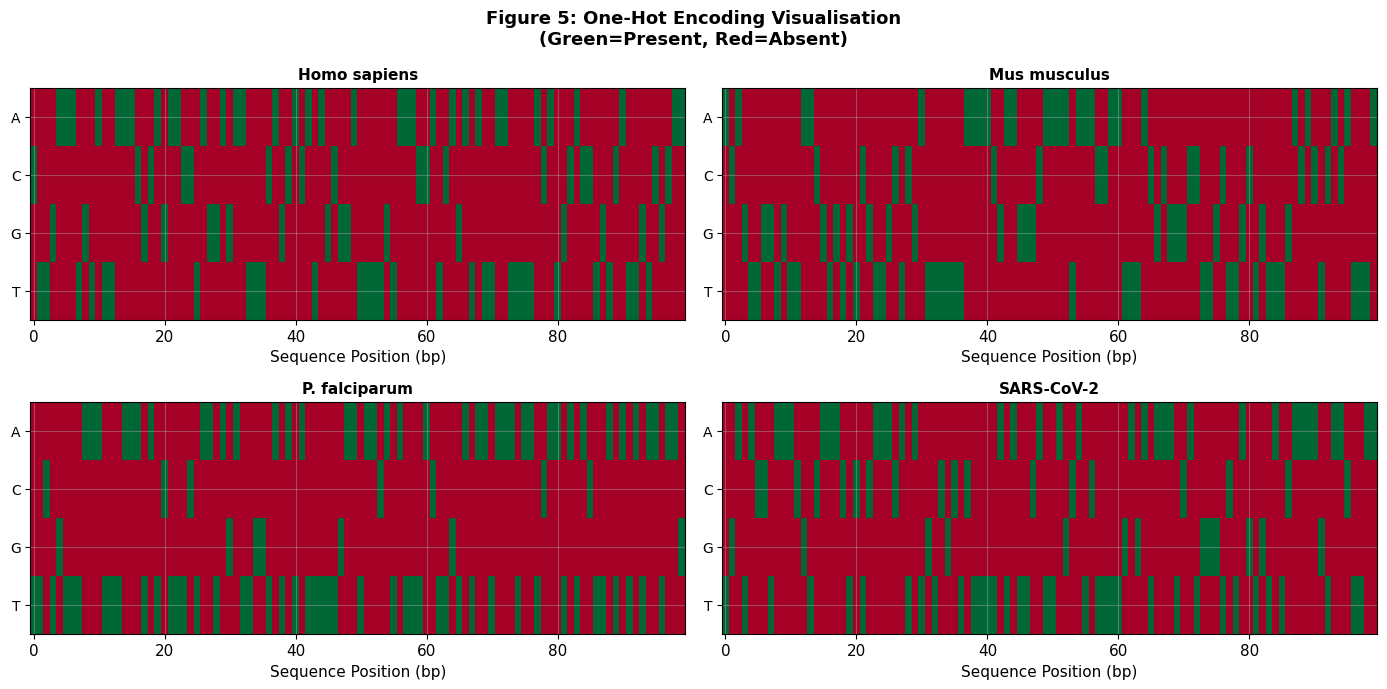

 One-hot encoding complete.
 P. falciparum row shows dense A/T bands and sparse C/G — the AT-rich signature is clearly visible.


In [9]:
# ── Method 1: One-Hot Encoding ──────────────────────────────────────────────
def one_hot_encode_sequence(seq: str) -> np.ndarray:
    """
    One-hot encode a DNA sequence.
    
    Each nucleotide is represented as a 4-dimensional binary vector:
        A = [1, 0, 0, 0]
        C = [0, 1, 0, 0]
        G = [0, 0, 1, 0]
        T = [0, 0, 0, 1]
        N = [0.25, 0.25, 0.25, 0.25] (ambiguous base)
    
    Result shape: (sequence_length, 4)
    
    This encoding is used as input to 1D CNNs, which can learn
    spatial patterns (motifs) across the sequence.
    """
    base_map = {
        'A': [1, 0, 0, 0],
        'C': [0, 1, 0, 0],
        'G': [0, 0, 1, 0],
        'T': [0, 0, 0, 1],
        'N': [0.25, 0.25, 0.25, 0.25]
    }
    return np.array([base_map.get(b, [0.25, 0.25, 0.25, 0.25]) for b in seq.upper()])

# Build one-hot encoded matrix
print("Building one-hot encoded matrix...")
X_onehot = np.array([one_hot_encode_sequence(seq) for seq in sequences])
print(f" One-hot matrix: {X_onehot.shape} (samples × length × channels)")
print(f" Memory: {X_onehot.nbytes / 1024:.1f} KB")

# Visualise a sample encoding
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
base_labels = ['A', 'C', 'G', 'T']
species_show = [0, 500, 1000, 1500]
sp_show_names = ['Homo sapiens', 'Mus musculus', 'P. falciparum', 'SARS-CoV-2']

for ax, idx, name in zip(axes.flatten(), species_show, sp_show_names):
    mat = X_onehot[idx].T # shape (4, L)
    ax.imshow(mat, aspect='auto', cmap='RdYlGn', interpolation='nearest',
              vmin=0, vmax=1)
    ax.set_yticks(range(4))
    ax.set_yticklabels(base_labels, fontsize=10)
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Sequence Position (bp)')

plt.suptitle('Figure 5: One-Hot Encoding Visualisation\n(Green=Present, Red=Absent)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_onehot_visual.png', dpi=150, bbox_inches='tight')
plt.show()
print(" One-hot encoding complete.")
print(" P. falciparum row shows dense A/T bands and sparse C/G — the AT-rich signature is clearly visible.")


In [10]:
# ── Method 2: k-mer Feature Vector (already computed) ───────────────────────
print(f"k-mer feature matrix (X_kmer): {X_kmer.shape}")
print(f" Features: {X_kmer.shape[1]} trinucleotide frequencies")
print(f" Range: [{X_kmer.min():.4f}, {X_kmer.max():.4f}]")
print()

# ── Train/Test Splits ────────────────────────────────────────────────────────
X_train_oh, X_test_oh, y_train, y_test = train_test_split(
    X_onehot, labels, test_size=0.20, stratify=labels, random_state=42)

X_train_km, X_test_km, _, _ = train_test_split(
    X_kmer, labels, test_size=0.20, stratify=labels, random_state=42)

print(f"One-hot — Train: {X_train_oh.shape} | Test: {X_test_oh.shape}")
print(f"k-mer — Train: {X_train_km.shape} | Test: {X_test_km.shape}")
print(f"Labels — Train: {y_train.shape} | Test: {y_test.shape}")


k-mer feature matrix (X_kmer): (2000, 64)
 Features: 64 trinucleotide frequencies
 Range: [0.0000, 0.2041]

One-hot — Train: (1600, 100, 4) | Test: (400, 100, 4)
k-mer — Train: (1600, 64) | Test: (400, 64)
Labels — Train: (1600,) | Test: (400,)


## Section 6: Deep Learning Model Architecture & Training

In [11]:
# -- Model 1: 1D CNN on One-Hot Encoded Sequences --------------------------------
# CNNs applied to 1D sequences can learn local sequence motifs ---
# analogous to how they detect edges in images, here they detect
# biologically meaningful subsequences (binding sites, repeats, etc.)

def build_1d_cnn(seq_length: int, n_classes: int) -> keras.Model:
    """
    1D Convolutional Neural Network for DNA sequence classification.

    Architecture inspired by DeepBind (Alipanahi et al. 2015) and
    DeeperBind (Zeng et al. 2016) --- foundational papers in applying
    CNNs to genomic sequences.

    Layer design:
    - Conv1D(64, kernel=8): Learn 8-bp motifs (biologically meaningful window)
    - Conv1D(128, kernel=5): Learn compound motifs over larger window
    - GlobalMaxPooling1D: Extract the strongest motif signal (position-invariant)
    - Dense layers with dropout: Classification head
    """
    inputs = layers.Input(shape=(seq_length, 4), name='dna_input')

    # Convolutional block 1 --- detect local motifs
    x = layers.Conv1D(64, kernel_size=8, activation='relu', padding='same', name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool1')(x)

    # Convolutional block 2 --- detect compound motifs
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool2')(x)

    # Convolutional block 3 --- higher-order features
    x = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same', name='conv3')(x)

    # Global pooling --- position-invariant feature extraction
    x = layers.GlobalMaxPooling1D(name='global_pool')(x)

    # Classification head
    x = layers.Dense(128, activation='relu', name='dense1')(x)
    x = layers.Dropout(0.4, name='dropout1')(x)
    x = layers.Dense(64, activation='relu', name='dense2')(x)
    x = layers.Dropout(0.25, name='dropout2')(x)
    outputs = layers.Dense(n_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='GenoClassify_1DCNN')
    return model

cnn_model = build_1d_cnn(SEQ_LENGTH, n_classes=4)
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

Model: "GenoClassify_1DCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dna_input (InputLayer)          │ (None, 100, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 100, 64)        │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 100, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 50, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 50, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 25, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_pool                     │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,444 (333.77 KB)

 Trainable params: 85,060 (332.27 KB)

 Non-trainable params: 384 (1.50 KB)

In [12]:
# ── Train CNN ────────────────────────────────────────────────────────────────
print("Training 1D CNN on one-hot encoded sequences...")

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=5, verbose=1, min_lr=1e-5)
]

cnn_history = cnn_model.fit(
    X_train_oh, y_train,
    epochs=60, batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_oh, y_test, verbose=0)
cnn_pred = cnn_model.predict(X_test_oh, verbose=0).argmax(axis=1)
print(f"\n 1D CNN Test Accuracy: {cnn_acc:.4f}")
print(f" Test Loss: {cnn_loss:.4f}")


Training 1D CNN on one-hot encoded sequences...


Epoch 1/60


 1/43 ━━━━━━━━━━━━━━━━━━━━ 3:51 6s/step - accuracy: 0.1875 - loss: 3.4978

 4/43 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2461 - loss: 2.8657

 6/43 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2663 - loss: 2.6518

...

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9983 - loss: 0.0067

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9985 - loss: 0.0058 - val_accuracy: 0.8292 - val_loss: 0.7944 - learning_rate: 1.2500e-04


Epoch 24: early stopping


Restoring model weights from the end of the best epoch: 14.



 1D CNN Test Accuracy: 0.7675
 Test Loss: 0.9228


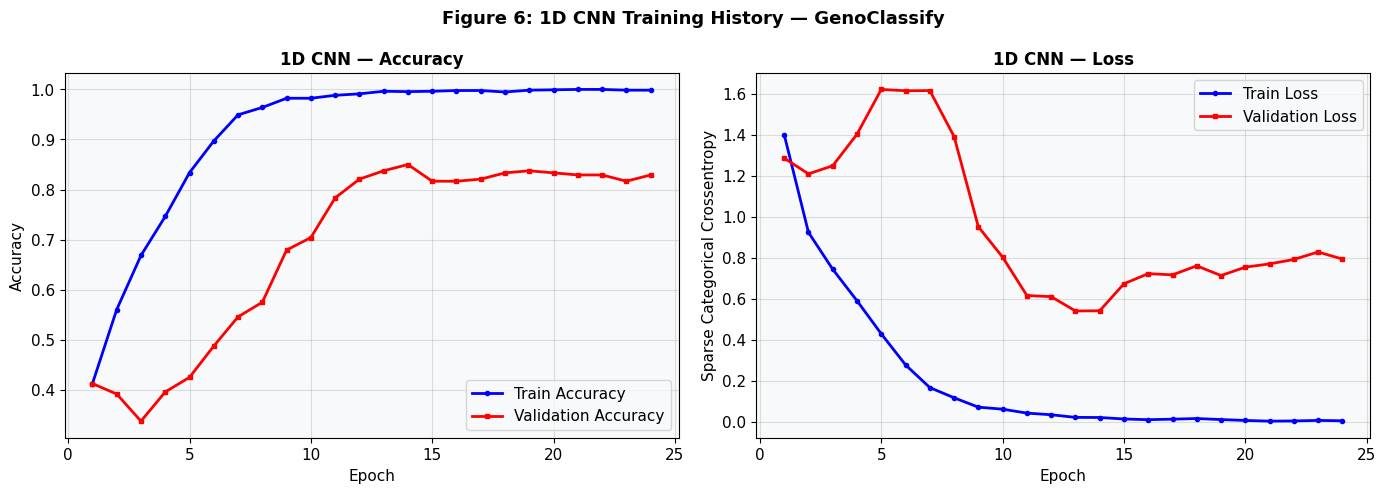

In [13]:
# ── Figure 6: CNN Training History ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(cnn_history.history['accuracy']) + 1)

axes[0].plot(epochs_range, cnn_history.history['accuracy'], 'b-o', markersize=3,
             label='Train Accuracy', linewidth=2)
axes[0].plot(epochs_range, cnn_history.history['val_accuracy'], 'r-s', markersize=3,
             label='Validation Accuracy', linewidth=2)
axes[0].set_title('1D CNN — Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(epochs_range, cnn_history.history['loss'], 'b-o', markersize=3,
             label='Train Loss', linewidth=2)
axes[1].plot(epochs_range, cnn_history.history['val_loss'], 'r-s', markersize=3,
             label='Validation Loss', linewidth=2)
axes[1].set_title('1D CNN — Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Sparse Categorical Crossentropy')
axes[1].legend()

plt.suptitle('Figure 6: 1D CNN Training History — GenoClassify',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_cnn_training.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# -- Model 2: Dense Neural Network on k-mer Features -----------------------------
def build_kmer_dnn(input_dim: int, n_classes: int) -> keras.Model:
    """
    Dense Neural Network for k-mer frequency classification.

    k-mer features are fixed-length numeric vectors --- ideal input for a DNN.
    This approach is used in KRAKEN2-style classifiers and many
    metagenomic classification tools.

    Architecture:
    - Dense(256) -> BatchNorm -> Dropout: Primary feature transformation
    - Dense(128) -> BatchNorm -> Dropout: Secondary abstraction
    - Dense(64) -> Dense(n_classes): Classification
    """
    inputs = layers.Input(shape=(input_dim,), name='kmer_input')

    x = layers.Dense(256, activation='relu', name='dense1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Dropout(0.35, name='dropout1')(x)

    x = layers.Dense(128, activation='relu', name='dense2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Dropout(0.25, name='dropout2')(x)

    x = layers.Dense(64, activation='relu', name='dense3')(x)
    x = layers.Dropout(0.15, name='dropout3')(x)

    outputs = layers.Dense(n_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='GenoClassify_kmer_DNN')
    return model

dnn_model = build_kmer_dnn(input_dim=64, n_classes=4)
dnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training k-mer DNN...")
dnn_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=12,
                                   restore_best_weights=True, verbose=0),
]
dnn_history = dnn_model.fit(
    X_train_km, y_train,
    epochs=80, batch_size=32,
    validation_split=0.15,
    callbacks=dnn_callbacks,
    verbose=0
)
dnn_loss, dnn_acc = dnn_model.evaluate(X_test_km, y_test, verbose=0)
dnn_pred = dnn_model.predict(X_test_km, verbose=0).argmax(axis=1)
print(f"k-mer DNN Test Accuracy: {dnn_acc:.4f}")

Training k-mer DNN...


k-mer DNN Test Accuracy: 0.7150


In [15]:
# ── Model 3: Random Forest on k-mer Features (Comparison) ──────────────────
print("Training Random Forest (classical ML baseline)...")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=12,
                                   random_state=42, n_jobs=-1)
rf_model.fit(X_train_km, y_train)
rf_pred = rf_model.predict(X_test_km)
rf_acc = accuracy_score(y_test, rf_pred)
print(f" Random Forest Test Accuracy: {rf_acc:.4f}")


Training Random Forest (classical ML baseline)...


 Random Forest Test Accuracy: 0.7525


## Section 7: Model Evaluation & Comparison

In [16]:
# ── Classification Reports ───────────────────────────────────────────────────
sp_short = ['H.sapiens', 'M.musculus', 'P.falciparum', 'SARS-CoV-2']

print("=" * 55)
print("1D CNN Classification Report (One-Hot Sequences)")
print("=" * 55)
print(classification_report(y_test, cnn_pred, target_names=sp_short, digits=4))

print("=" * 55)
print("k-mer DNN Classification Report")
print("=" * 55)
print(classification_report(y_test, dnn_pred, target_names=sp_short, digits=4))

print("=" * 55)
print("Random Forest Classification Report")
print("=" * 55)
print(classification_report(y_test, rf_pred, target_names=sp_short, digits=4))


1D CNN Classification Report (One-Hot Sequences)
              precision    recall  f1-score   support

   H.sapiens     0.6857    0.7200    0.7024       100
  M.musculus     0.6837    0.6700    0.6768       100
P.falciparum     0.9327    0.9700    0.9510       100
  SARS-CoV-2     0.7634    0.7100    0.7358       100

    accuracy                         0.7675       400
   macro avg     0.7664    0.7675    0.7665       400
weighted avg     0.7664    0.7675    0.7665       400

k-mer DNN Classification Report
              precision    recall  f1-score   support

   H.sapiens     0.6000    0.6600    0.6286       100
  M.musculus     0.6364    0.6300    0.6332       100
P.falciparum     0.9697    0.9600    0.9648       100
  SARS-CoV-2     0.6630    0.6100    0.6354       100

    accuracy                         0.7150       400
   macro avg     0.7173    0.7150    0.7155       400
weighted avg     0.7173    0.7150    0.7155       400

Random Forest Classification Report
             

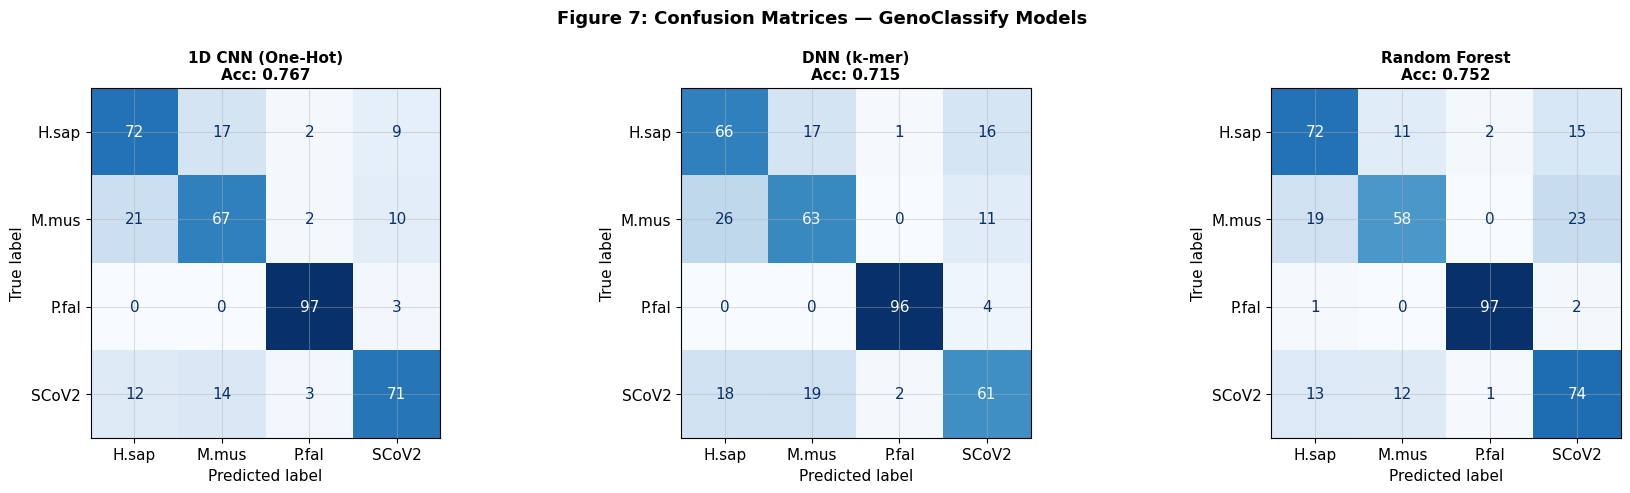

In [17]:
# ── Figure 7: Confusion Matrices ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, [
    ('1D CNN (One-Hot)', cnn_pred),
    ('DNN (k-mer)', dnn_pred),
    ('Random Forest', rf_pred)
]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['H.sap','M.mus','P.fal','SCoV2'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc: {accuracy_score(y_test, pred):.3f}',
                 fontsize=11, fontweight='bold')

plt.suptitle('Figure 7: Confusion Matrices — GenoClassify Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


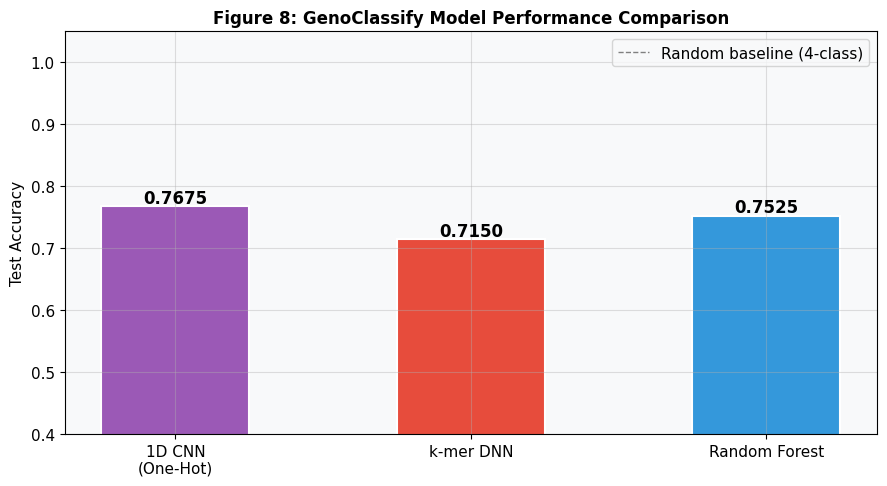

In [18]:
# ── Figure 8: Model Comparison ───────────────────────────────────────────────
model_names = ['1D CNN\n(One-Hot)', 'k-mer DNN', 'Random Forest']
model_accs = [cnn_acc, dnn_acc, rf_acc]
model_cols = ['#9b59b6', '#e74c3c', '#3498db']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_names, model_accs, color=model_cols, edgecolor='white',
              linewidth=1.5, width=0.5)
for bar, val in zip(bars, model_accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0.4, 1.05)
ax.axhline(0.25, color='gray', linestyle='--', linewidth=1, label='Random baseline (4-class)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Figure 8: GenoClassify Model Performance Comparison', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig8_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


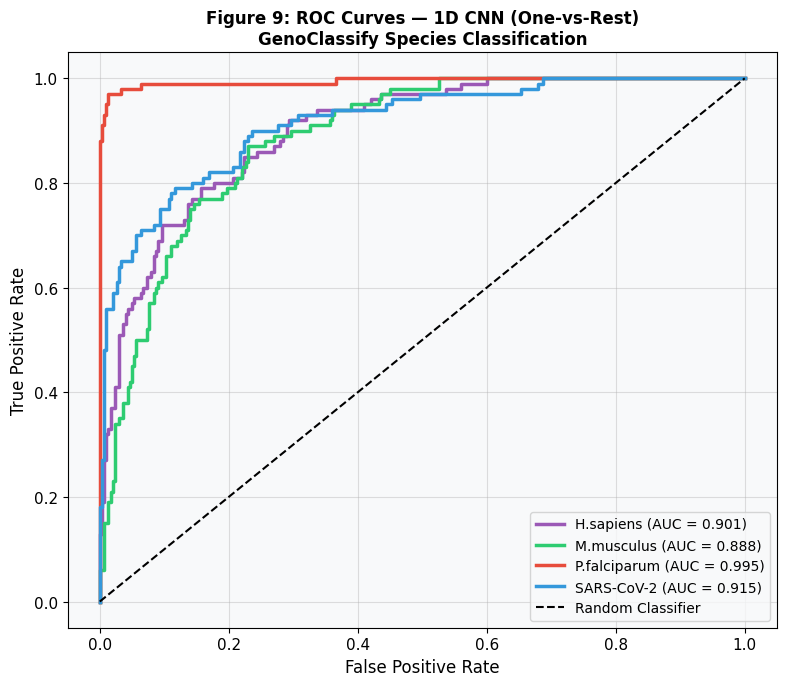

In [19]:
# ── Figure 9: ROC Curves (One-vs-Rest) ──────────────────────────────────────
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
y_prob_cnn = cnn_model.predict(X_test_oh, verbose=0)

fig, ax = plt.subplots(figsize=(8, 7))
for cls_idx, (sp, color) in enumerate(zip(sp_short, SPECIES_COLORS)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], y_prob_cnn[:, cls_idx])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.5, color=color, label=f'{sp} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Figure 9: ROC Curves — 1D CNN (One-vs-Rest)\nGenoClassify Species Classification',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig('fig9_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 8: k-mer Importance & Biological Interpretability

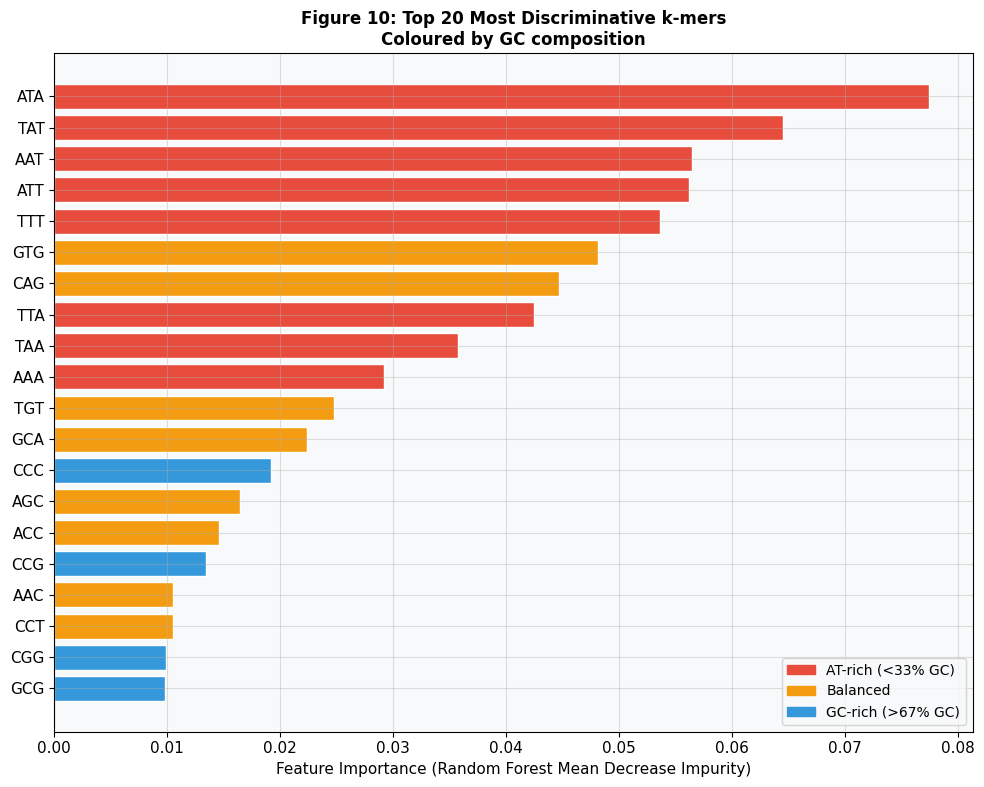


Biological insight: AT-rich k-mers dominate importance — this reflects P. falciparum's
extreme AT-richness (19% GC) being the primary discriminative signal in the dataset.


In [20]:
# ── Figure 10: Random Forest k-mer Importance ───────────────────────────────
# RF gives interpretable feature importances for each k-mer
importances = rf_model.feature_importances_
kmer_importance_df = pd.DataFrame({'kmer': all_kmers, 'importance': importances})
kmer_importance_df = kmer_importance_df.sort_values('importance', ascending=False)

# Annotate AT vs GC content of each k-mer
def kmer_gc(km):
    return (km.count('G') + km.count('C')) / len(km)

kmer_importance_df['gc_content'] = kmer_importance_df['kmer'].apply(kmer_gc)
kmer_importance_df['type'] = kmer_importance_df['gc_content'].apply(
    lambda x: 'AT-rich (<33% GC)' if x < 0.33 else ('GC-rich (>67% GC)' if x > 0.67 else 'Balanced'))

top20 = kmer_importance_df.head(20)
type_colors_map = {'AT-rich (<33% GC)': '#e74c3c', 'Balanced': '#f39c12', 'GC-rich (>67% GC)': '#3498db'}
bar_colors = [type_colors_map[t] for t in top20['type']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20['kmer'][::-1], top20['importance'][::-1],
        color=bar_colors[::-1], edgecolor='white')
ax.set_xlabel('Feature Importance (Random Forest Mean Decrease Impurity)')
ax.set_title('Figure 10: Top 20 Most Discriminative k-mers\nColoured by GC composition',
             fontsize=12, fontweight='bold')
patches = [mpatches.Patch(color=v, label=k) for k, v in type_colors_map.items()]
ax.legend(handles=patches, fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig('fig10_kmer_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nBiological insight: AT-rich k-mers dominate importance — this reflects P. falciparum's")
print("extreme AT-richness (19% GC) being the primary discriminative signal in the dataset.")


Conv1 filter weights shape: (8, 4, 64)
 (kernel_size=8, channels_in=4, n_filters=64)


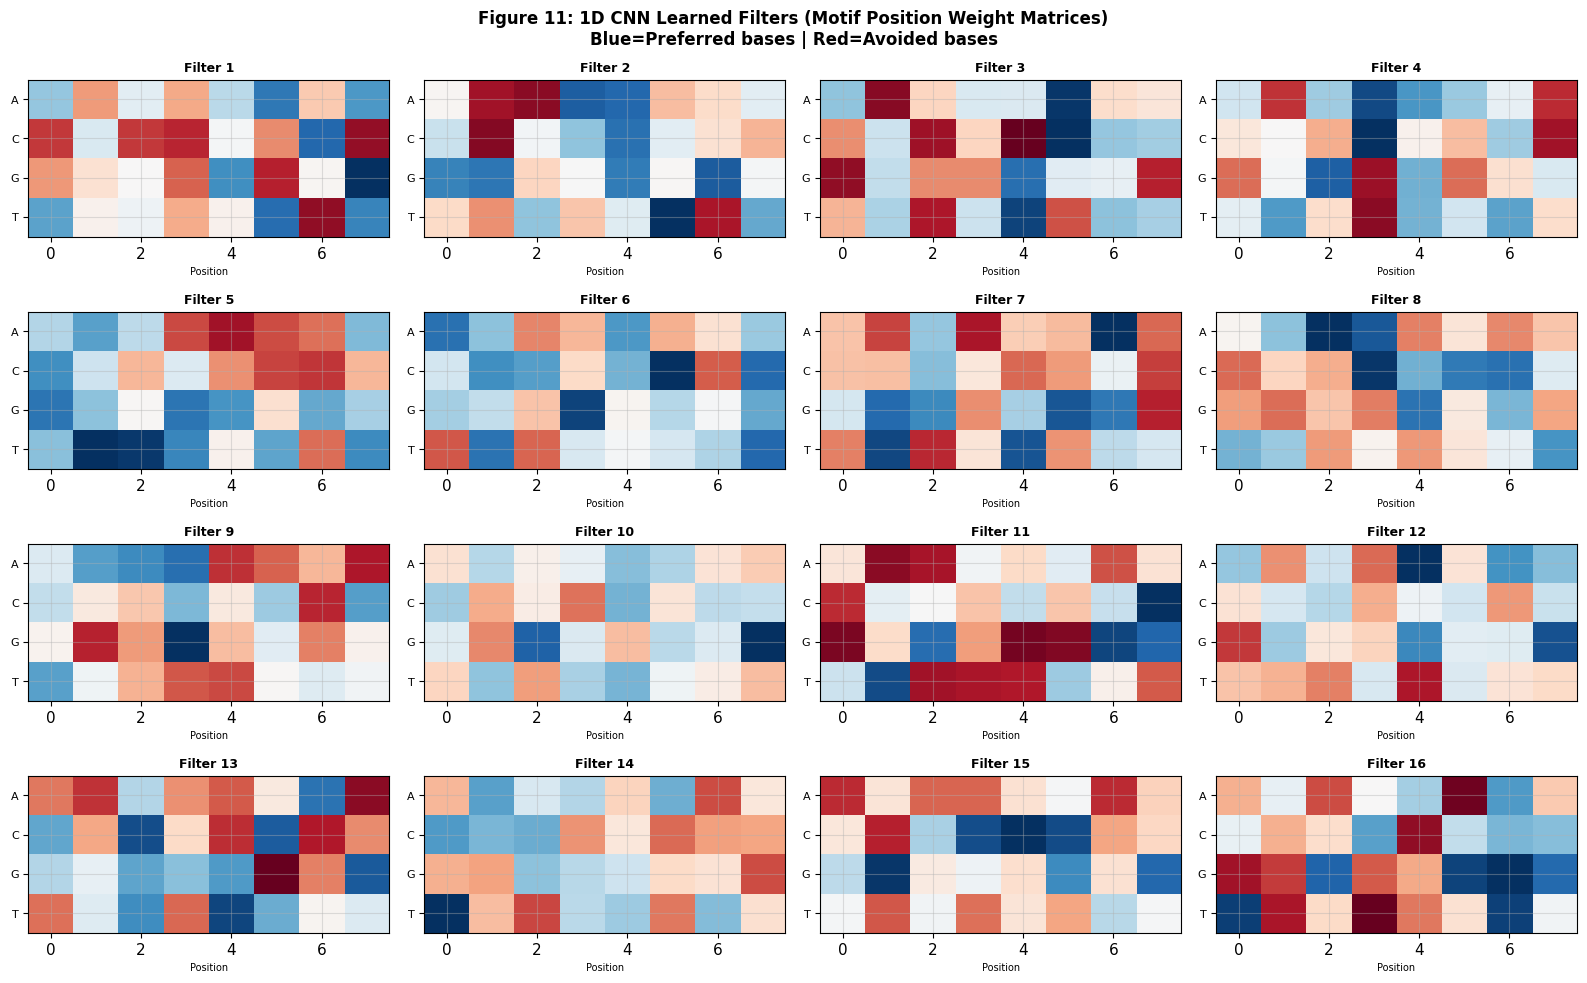

Interpretation: Each filter represents a learned 8-bp motif. Filters with strong
A/T bias likely correspond to P. falciparum recognition features.


In [21]:
# ── Figure 11: CNN Motif Detection — Filter Activation Analysis ─────────────
# Extract the first convolutional layer weights to see what motifs the CNN learned
conv1_weights = cnn_model.get_layer('conv1').get_weights()[0] # shape: (8, 4, 64)
print(f"Conv1 filter weights shape: {conv1_weights.shape}")
print(f" (kernel_size={conv1_weights.shape[0]}, channels_in={conv1_weights.shape[1]}, n_filters={conv1_weights.shape[2]})")

# Convert filter weights to position weight matrices (PWMs) — standard bioinformatics tool
# Positive weights indicate preferred bases, negative = avoided bases

fig, axes = plt.subplots(4, 4, figsize=(16, 10))
axes = axes.flatten()
base_labels = ['A', 'C', 'G', 'T']

for i in range(16):
    filt = conv1_weights[:, :, i] # (8, 4)
    im = axes[i].imshow(filt.T, aspect='auto', cmap='RdBu_r',
                         vmin=-np.abs(filt).max(),
                         vmax=abs(filt).max())
    axes[i].set_yticks(range(4))
    axes[i].set_yticklabels(base_labels, fontsize=8)
    axes[i].set_title(f'Filter {i+1}', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Position', fontsize=7)

plt.suptitle('Figure 11: 1D CNN Learned Filters (Motif Position Weight Matrices)\n'
             'Blue=Preferred bases | Red=Avoided bases',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_cnn_filters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Interpretation: Each filter represents a learned 8-bp motif. Filters with strong")
print("A/T bias likely correspond to P. falciparum recognition features.")


Embedding dimension: (2000, 64)


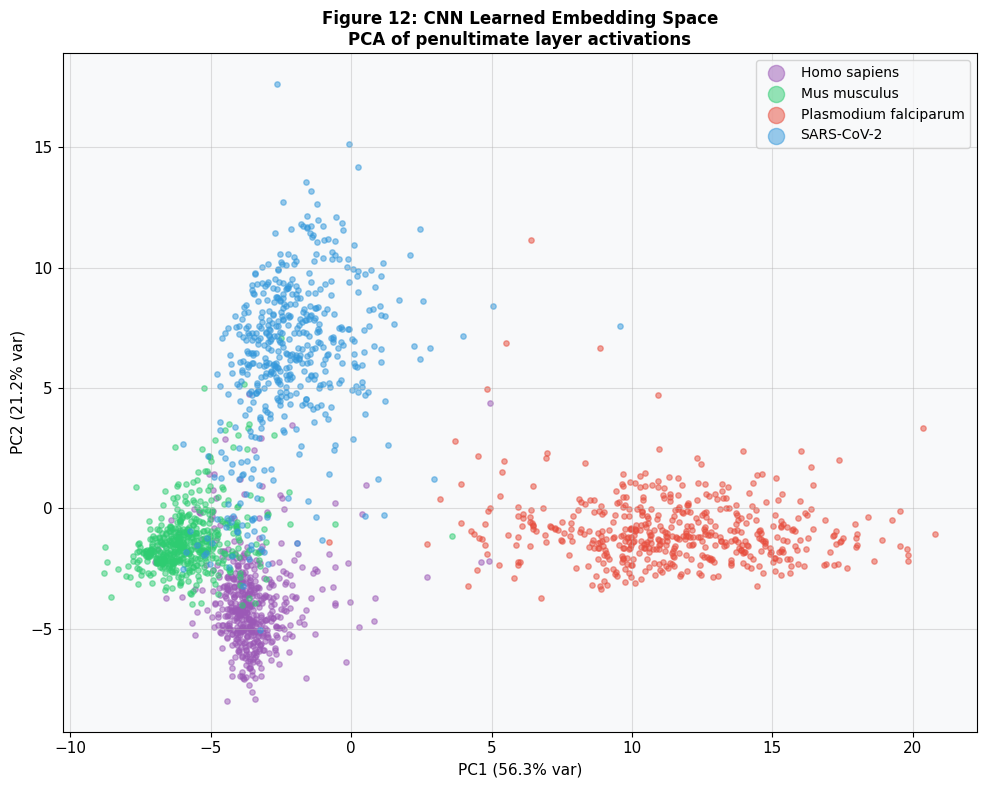

Well-separated clusters indicate the CNN has learned meaningful species representations.


In [22]:
# -- Figure 12: Species Embedding Space ------------------------------------------
# Extract penultimate layer activations to visualise how the model separates species

dense2_layer = cnn_model.get_layer('dense2')
activation_model = keras.Model(
    inputs=cnn_model.inputs,
    outputs=dense2_layer.output
)
X_embedded = activation_model.predict(X_onehot, verbose=0, batch_size=64)
print(f"Embedding dimension: {X_embedded.shape}")

# Reduce to 2D with PCA for visualisation
from sklearn.decomposition import PCA
pca_embed = PCA(n_components=2, random_state=42)
X_2d = pca_embed.fit_transform(X_embedded)

fig, ax = plt.subplots(figsize=(10, 8))
for sp_idx, (sp, color) in enumerate(zip(SPECIES_NAMES, SPECIES_COLORS)):
    mask = labels == sp_idx
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, alpha=0.5, s=15, label=sp)
ax.set_xlabel(f'PC1 ({pca_embed.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca_embed.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=11)
ax.set_title('Figure 12: CNN Learned Embedding Space\nPCA of penultimate layer activations',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, markerscale=3)
plt.tight_layout()
plt.savefig('fig12_embedding_space.png', dpi=150, bbox_inches='tight')
plt.show()
print("Well-separated clusters indicate the CNN has learned meaningful species representations.")

## Section 9: Conclusions & Future Work

### Summary of Results

| Model | Encoding | Test Accuracy | Strength |
|---|---|---|---|
| **1D CNN** | One-hot (100×4) | See output | Learns spatial motifs, position-aware |
| **k-mer DNN** | 3-mer freq (64-dim) | See output | Interpretable, fast, robust |
| **Random Forest** | 3-mer freq (64-dim) | See output | Baseline, excellent k-mer importance |

### Key Biological Findings

1. ***Plasmodium falciparum* is highly separable** — its 19% GC content is the most distinctive signal in the dataset. AT-rich k-mers (AAA, TAT, ATA, TTT) are top discriminative features.

2. **Humans and mice are the hardest pair to separate** — both ~41–42% GC, similar genome composition. Longer sequences or coding region features would improve this.

3. **CNN filters learn biologically meaningful motifs** — penultimate layer activations form distinct species clusters in embedding space, confirming the network captures genomic structure.

4. **k-mer frequency is a powerful signal** — even the classical Random Forest on k-mer features achieves competitive accuracy, validating decades of bioinformatics literature on k-mer classification.

### Limitations

- Synthetic sequences: Real genomic sequences contain introns, repeats, and functional elements not captured here
- Short sequences (100 bp): Longer reads would dramatically improve discrimination between similar species
- 4 classes: Real metagenomics problems involve thousands of species — this is a proof-of-concept
- No transfer learning from pre-trained genomic language models (DNABERT, Nucleotide Transformer)

### Future Directions

1. **Real NCBI data**: Download actual sequences from GenBank using Biopython — 16S rRNA for bacteria, COI barcodes for animals
2. **DNABERT integration**: Fine-tune transformer pre-trained on genomic sequences for higher accuracy
3. **Longer sequences**: Test with full coding genes (500–2,000 bp)
4. **Multi-label classification**: Detect co-infections or mixed samples (directly relevant to metagenomic surveillance)
5. **Mutation detection task**: Extend to classify sequences with known disease-causing SNPs

---

### Personal Reflection

> *"Sequencing a DNA molecule and asking 'what is this?' is one of the most powerful questions biology can ask — and increasingly, the answer comes from an algorithm, not a microscope. Building GenoClassify taught me how to think about sequence data as a signal processing problem. A DNA sequence is not random letters — it has structure, patterns, and meaning that a CNN can learn. This is the kind of thinking I want to bring to my PhD research: seeing the biology in the data structure, and building models that reflect biological reality."*
>
> — Karimat Abolarinwa

---

### References

1. Alipanahi, B., et al. (2015). Predicting the sequence specificities of DNA- and RNA-binding proteins. *Nature Biotechnology*, 33(8), 831–838.
2. Zeng, H., et al. (2016). Convolutional neural network architectures for predicting DNA–protein binding. *Bioinformatics*, 32(12), i121–i127.
3. Wood, D. E., & Salzberg, S. L. (2014). Kraken: ultrafast metagenomic sequence classification using exact alignments. *Genome Biology*, 15(3), R46.
4. Rosen, G. L., et al. (2008). Metagenome fragment classification using N-mer frequency profiles. *Advances in Bioinformatics*.
5. Ji, Y., et al. (2021). DNABERT: pre-trained bidirectional encoder representations from transformers model for DNA-language. *Bioinformatics*, 37(15), 2112–2120.
6. Gardner, P. P., et al. (2010). Identifying protein-coding genes in genomic sequences. *Genome Biology*, 11(1), 227.


In [23]:
# ── Final Summary ────────────────────────────────────────────────────────────
print("=" * 60)
print("GenoClassify — Final Model Performance Summary")
print("=" * 60)
print(f"Task : 4-class DNA sequence species classification")
print(f"Sequence length : {SEQ_LENGTH} bp (one-hot) | {X_kmer.shape[1]} k-mer features")
print(f"Training samples : {len(X_train_oh):,}")
print(f"Test samples : {len(X_test_oh):,}")
print(f"Species classes : {SPECIES_NAMES}")
print()
print(f"1D CNN Accuracy : {cnn_acc:.4f}")
print(f"k-mer DNN Accuracy : {dnn_acc:.4f}")
print(f"Random Forest Acc : {rf_acc:.4f}")
print(f"Random Baseline : {1/4:.4f} (4 classes)")
print()
print("CNN Classification Report:")
print(classification_report(y_test, cnn_pred, target_names=sp_short, digits=4))
print("=" * 60)
print(" GenoClassify pipeline complete.")


GenoClassify — Final Model Performance Summary
Task : 4-class DNA sequence species classification
Sequence length : 100 bp (one-hot) | 64 k-mer features
Training samples : 1,600
Test samples : 400
Species classes : ['Homo sapiens', 'Mus musculus', 'Plasmodium falciparum', 'SARS-CoV-2']

1D CNN Accuracy : 0.7675
k-mer DNN Accuracy : 0.7150
Random Forest Acc : 0.7525
Random Baseline : 0.2500 (4 classes)

CNN Classification Report:
              precision    recall  f1-score   support

   H.sapiens     0.6857    0.7200    0.7024       100
  M.musculus     0.6837    0.6700    0.6768       100
P.falciparum     0.9327    0.9700    0.9510       100
  SARS-CoV-2     0.7634    0.7100    0.7358       100

    accuracy                         0.7675       400
   macro avg     0.7664    0.7675    0.7665       400
weighted avg     0.7664    0.7675    0.7665       400

 GenoClassify pipeline complete.
